In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


# Magnetic Diagnostics: Synthetic Mirnov SVD and Wavelet

This notebook demonstrates the magnetic-diagnostic workflow using **synthetic** multichannel data. It is not a reconstruction of IR-T1 experimental data.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parents[1]))

In [3]:
from synthetic_data.magnetic.mirnov import generate_synthetic_mirnov_dataset
from core.signal_processing import remove_offset, detrend_signal, compute_psd
from magnetic_diagnostics.wavelet import compute_cwt
from magnetic_diagnostics.svd import compute_svd
from magnetic_diagnostics import visualization as viz

data = generate_synthetic_mirnov_dataset()
data.data.shape

(12, 10000)

/tmp/ipykernel_7071/3815531004.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


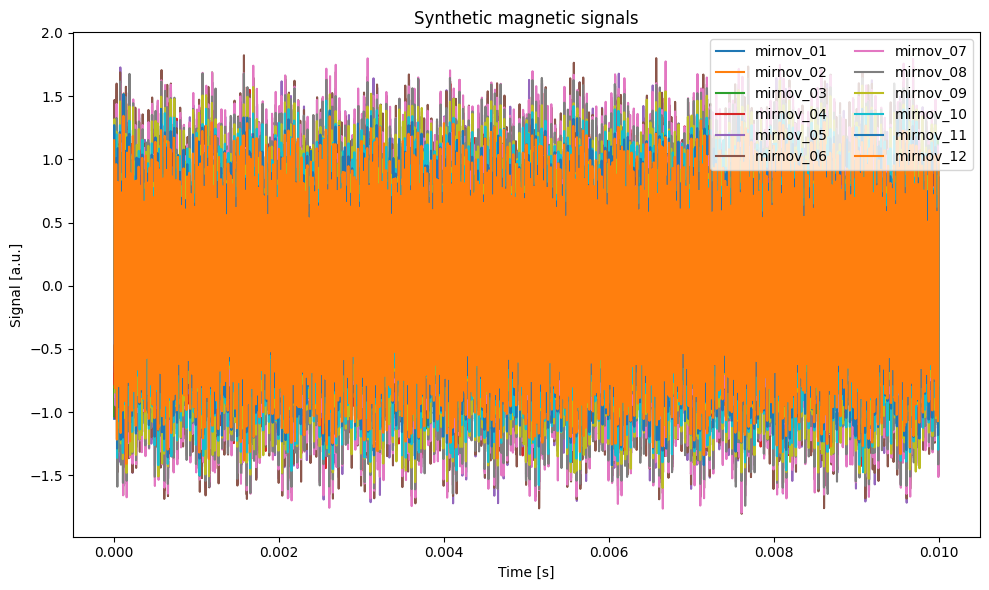

In [4]:
fig, ax = viz.plot_multichannel_signals(data.time, data.data, channel_names=data.channel_names)
fig.show()

## Preprocessing
The common signal-processing core is reused; no magnetic-specific duplicate implementation is introduced.

/tmp/ipykernel_7071/1195738984.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


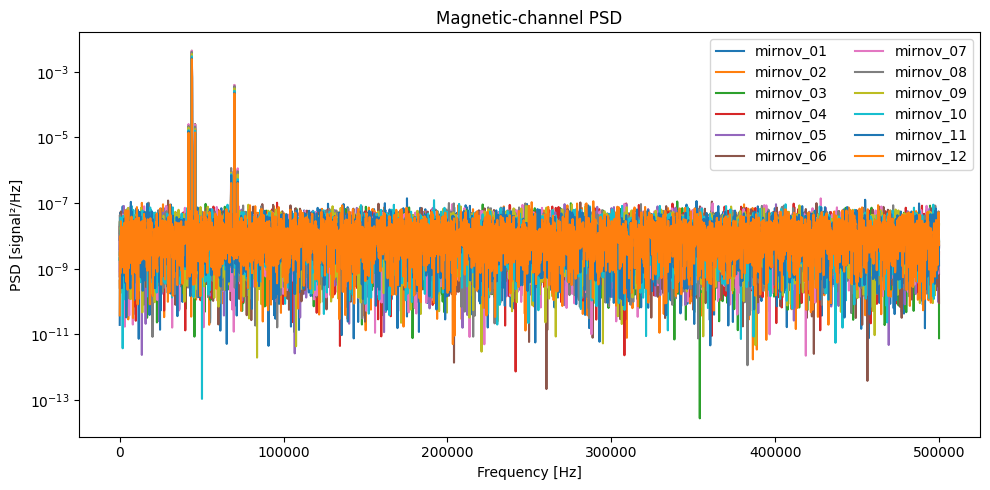

In [5]:
processed = detrend_signal(remove_offset(data.data))
f, psd = compute_psd(processed, data.sampling_frequency, nperseg=data.n_samples)
fig, ax = viz.plot_psd(f, psd, channel_names=data.channel_names)
fig.show()

/tmp/ipykernel_7071/1825612993.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


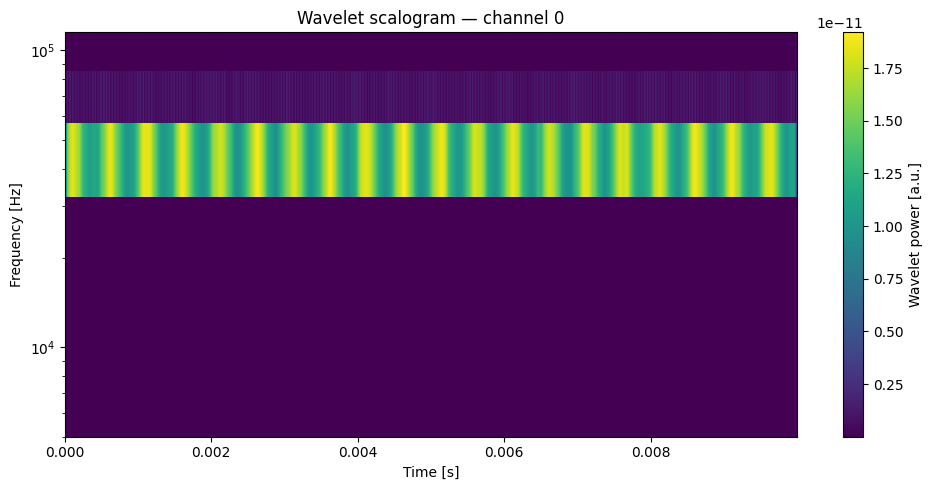

In [6]:
coefficients, frequencies, scales = compute_cwt(processed[0], data.sampling_frequency, frequencies=[10_000, 20_000, 44_000, 70_000, 100_000])
fig, ax = viz.plot_wavelet_scalogram(data.time, frequencies, coefficients)
fig.show()

/tmp/ipykernel_7071/554169459.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_7071/554169459.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


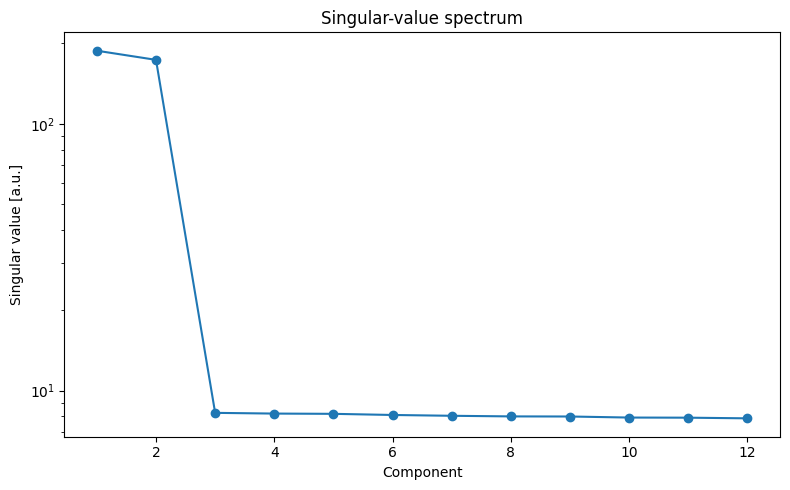

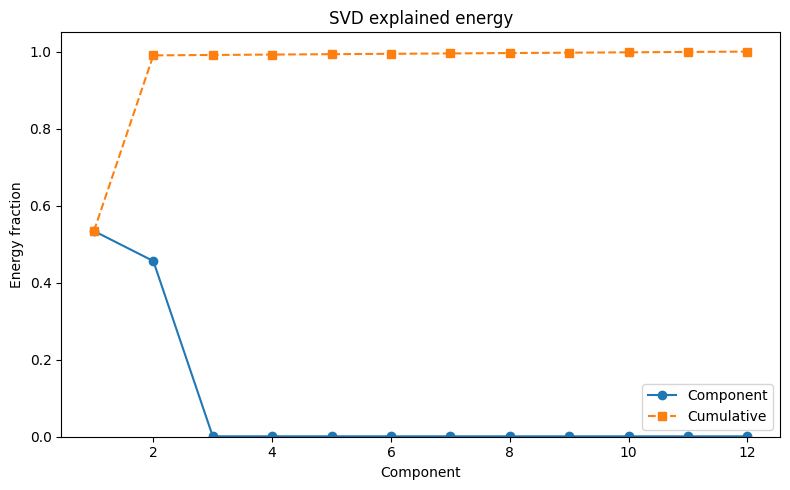

In [7]:
svd = compute_svd(data)
fig, ax = viz.plot_singular_values(svd.singular_values)
fig.show()

fig, ax = viz.plot_svd_energy(svd.singular_values)
fig.show()

/tmp/ipykernel_7071/3311828602.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_7071/3311828602.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


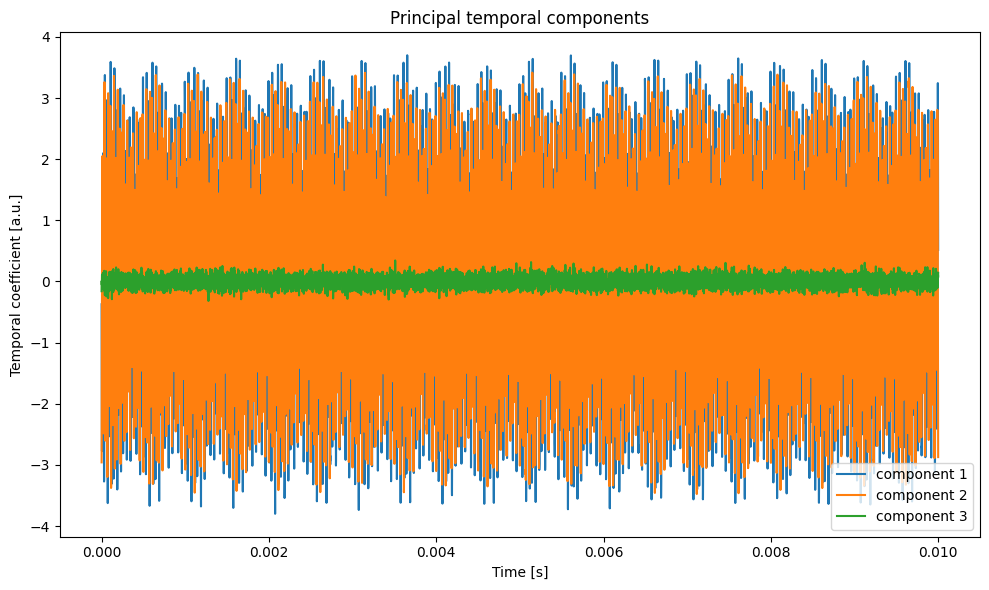

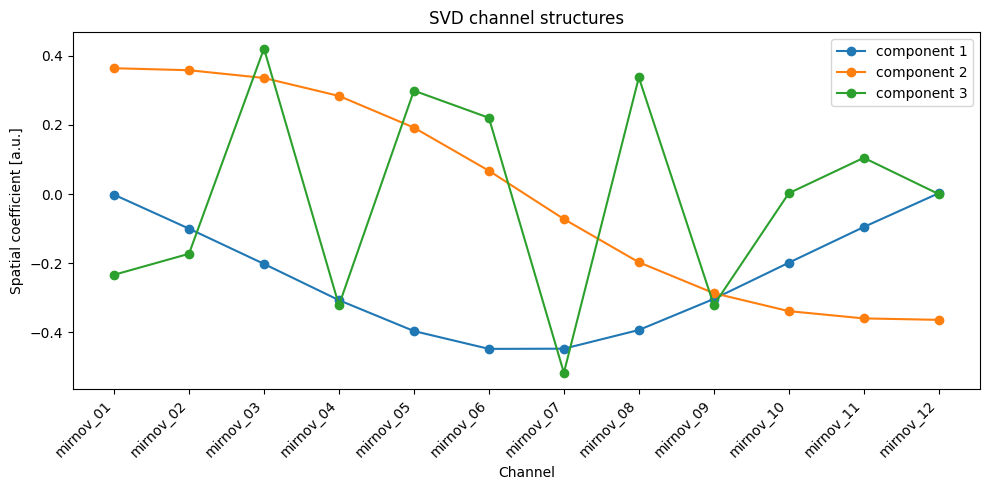

In [8]:
fig, ax = viz.plot_temporal_components(data.time, svd.temporal_components, n_components=3)
fig.show()

fig, ax = viz.plot_spatial_structures(data.channel_names, svd.u, n_components=3)
fig.show()

## Interpretation
The workflow demonstrates frequency-domain, time-frequency, and multichannel decomposition of a controlled synthetic magnetic dataset. SVD structures are mathematical coherent structures; they are not automatically identified as physical MHD modes.